# 強度の導入

In [8]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8


In [9]:
import pandas as pd

spike_long = pd.read_csv(
    "../data/processed/spike_long.csv",
    parse_dates=["date"]
)

spike_long.head()

,index,date,area,time_code,price,u,x
0,0,2016-04-01,Chubu,1,6.69,0,0.0
1,1,2016-04-01,Chubu,2,6.34,0,0.0
2,2,2016-04-01,Chubu,3,6.34,0,0.0
3,3,2016-04-01,Chubu,4,6.03,0,0.0
4,4,2016-04-01,Chubu,5,6.57,0,0.0


In [10]:
u_tokyo = pd.read_csv(
    "../data/processed/u_dict/u_Tokyo.csv",
    index_col=0,
    parse_dates=True
)

u_tokyo.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-04-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
x_tokyo = pd.read_csv(
    "../data/processed/x_dict/x_Tokyo.csv",
    index_col=0,
    parse_dates=True
)

x_tokyo.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
date,,,,,,,,,,,,,,,,,,,,,
2016-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


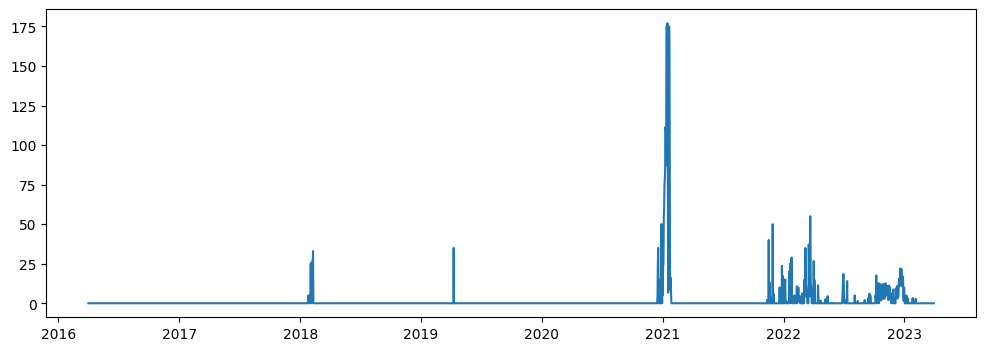

In [12]:
plt.figure(figsize=(12,4))
plt.plot(x_tokyo["15"])
plt.show()

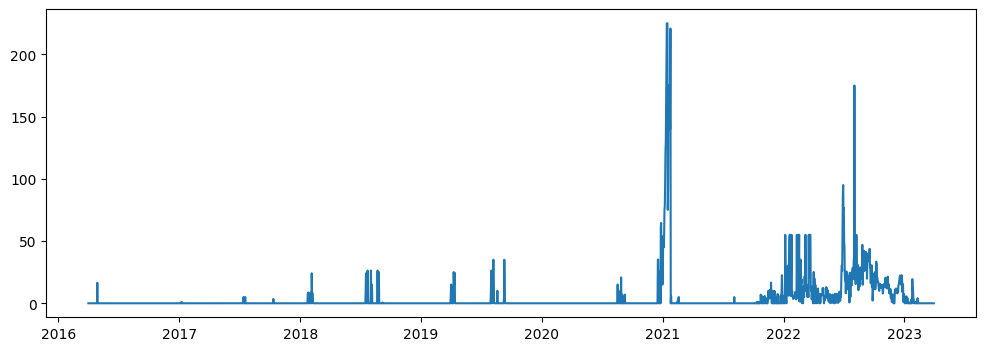

In [13]:
plt.figure(figsize=(12,4))
plt.plot(x_tokyo["37"])
plt.show()

## モデル
強度$\lambda_d$を以下で定義して、$\alpha , \beta , \gamma$の推定を逐次ベイズ推定することが目標。

### Hawkes I

$$
\lambda_d = \alpha \lambda_{d-1} + \beta + \gamma u_d
$$

$$
\alpha = \exp{\left(-\frac{1}{\tau}\right)}\ , \ \beta = \mu(1- \alpha)
$$

$$
\gamma : \text{スパイクが来た時のジャンプ量}
$$

### Hawkes II
強いショックは強い連鎖を生む

$$
\lambda_d = \alpha \lambda_{d-1} + \beta + \gamma_d u_d
$$

$$
\gamma_d = \gamma_0 (1 - \exp{\left( -\frac{x_d}{x_0}\right)})
$$

### Hawkes III
強いショックは長く尾を引く

$$
\lambda_d = \alpha_d \lambda_{d-1} + \beta + \gamma u_d
$$

$$
\tau_d = \tau_0 (1 - \exp{\left( -\frac{x_d}{x_0}\right)})
$$

In [14]:
def compute_lambda(u, alpha, beta, gamma):
    lambda_series = []
    lam = beta / (1 - alpha)  # 初期値（定常値）

    for ud in u:
        lam = alpha * lam + beta + gamma * ud
        lambda_series.append(lam)

    return np.array(lambda_series)

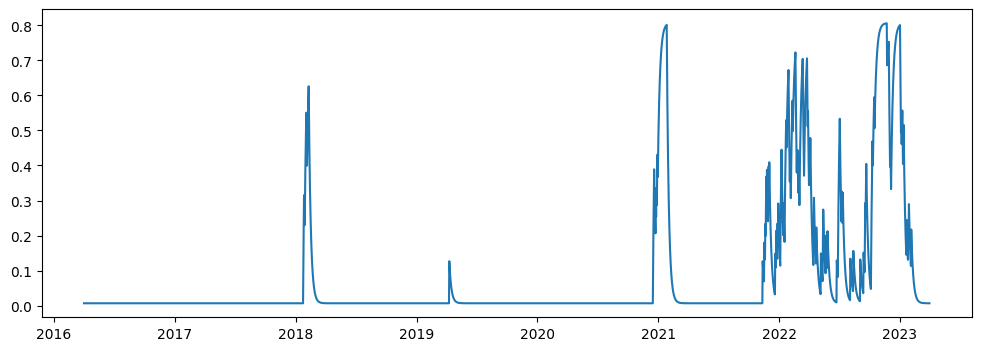

In [15]:
plt.figure(figsize=(12,4))
u = u_tokyo["15"].values
lambda_tokyo_15 = compute_lambda(u, alpha=0.85, beta=0.001, gamma=0.12)
plt.plot(u_tokyo["15"].index,lambda_tokyo_15)